<a href="https://colab.research.google.com/github/algaebrown/RBPNet/blob/main/rbpnet_colab_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U "huggingface_hub[cli]"
!hf download yeolab/eCLIP \
    --repo-type dataset \
    --include "RBFOX2_HepG2_ENCSR987FTF/**" \
    --local-dir eCLIP

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files: 100% 5/5 [00:00<00:00, 2697.65it/s]
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B                         ✓ Downloaded
  path: /content/eCLIP
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            


In [2]:
from datasets import load_dataset

ds = load_dataset(
    "yeolab/eCLIP",
    name="RBFOX2_HepG2_ENCSR987FTF",
)

In [3]:
!pip install seqpro

In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import seqpro as sp

class ECLIPDataset(Dataset):
    def __init__(self, hf_dataset):
        self.ds = hf_dataset

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]

        seq = np.char.upper(ex["seq"])
        seq = sp.ohe(seq, sp.alphabets.DNA).swapaxes(0, 1)

        control = np.asarray(ex["control"], dtype=np.float32)
        signal = np.asarray(ex["signal"], dtype=np.float32)

        return {
            "seq": torch.from_numpy(seq).float(),
            "control": torch.from_numpy(control).float(),
            "signal": torch.from_numpy(signal).float(),
            "gc_fraction": torch.tensor(ex["gc_fraction"], dtype=torch.float32),
            "n_IN": torch.tensor(ex["n_IN"], dtype=torch.float32),
            "n_IP": torch.tensor(ex["n_IP"], dtype=torch.float32),
        }
train_dataset = ECLIPDataset(ds["train"])

train_dl = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=True,
    num_workers=4,
)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [27]:
valid_dataset = ECLIPDataset(ds["validation"])
valid_dl = DataLoader(
    valid_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=True,
    num_workers=4,
)

test_dataset = ECLIPDataset(ds["test"])
test_dl = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=True,
    drop_last=True,
    num_workers=4,
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [25]:
for dset in ['test', 'train', 'validation']:
  chroms = ds[dset].unique("chrom")
  print(dset, ':', chroms)

test : ['chr2', 'chr9', 'chr16']
train : ['chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22']
validation : ['chr1', 'chr8', 'chr15']


In [6]:
!git clone https://github.com/algaebrown/RBPNet.git

fatal: destination path 'RBPNet' already exists and is not an empty directory.


In [7]:
!ls RBPNet

dataload.py   metrics.py    RBPNet.py		score_gnomAD.py  validate.py
inference.py  module.py     readme.md		score_rMATs.py
LICENSE       prep_data.py  score_fa_nomask.py	seqlet.py
losses.py     __pycache__   score_fa.py		train.py


In [8]:
# architecture
import sys
sys.path.append("RBPNet")
from RBPNet import RBPNet
mask = 100
arch = RBPNet(mask = mask)

In [9]:
!pip install pytorch-lightning

In [10]:
### Module ###
from module import Module
from losses import rbpnet_loss
from metrics import rbpnet_metrics, dlog_odds_from_data
# LightningModule
module = Module(
    arch=arch,
    input_variables=["seq"],
    output_variables=["eCLIP_profile", "signal_profile", "control_profile", "mixing_coefficient",
                    "d_log_odds"],
    target_variables=["signal", "control", "gc_fraction", "n_IN", "n_IP"],
    loss_fxn=rbpnet_loss,
    metrics_fxn=rbpnet_metrics
)


In [11]:
from genericpath import exists
# Logger
import os
log_dir = './log'
if not exists(log_dir):
    os.makedirs(log_dir)

from pytorch_lightning.loggers import CSVLogger
logger = CSVLogger(save_dir=log_dir, name="", version="")

# Set-up callbacks
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.lr_monitor import LearningRateMonitor
callbacks = []
model_checkpoint_callback = ModelCheckpoint(
    dirpath=os.path.join(
        logger.save_dir,
        logger.name,
        logger.version,
        "checkpoints"
    ),
    save_top_k=5,
    monitor="val_loss_epoch",
)
callbacks.append(model_checkpoint_callback)
early_stopping_callback = EarlyStopping(
    monitor="val_loss_epoch",
    patience=10,
    mode="min",
    verbose=True,
    #check_on_train_epoch_end=False ###https://github.com/Lightning-AI/pytorch-lightning/issues/9151
)
callbacks.append(early_stopping_callback)
callbacks.append(LearningRateMonitor())
callbacks



In [12]:
# Trainer
from pytorch_lightning import Trainer
trainer = Trainer(
    max_epochs=20,
    logger=logger,
    devices="auto",
    accelerator="auto",
    callbacks=callbacks,
    num_sanity_val_steps=2
)

# Fit
trainer.fit(
    module,
    train_dataloaders=train_dl,
    val_dataloaders=valid_dl,
)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory ./log/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/log/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ arch │ RBPNet │  899 K │ train │     0 │
└───┴──────┴────────┴────────┴───────┴───────┘

Trainable params: 899 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 899 K                                                                                                
Total estimated model params size (MB): 3.599                                                                      
Modules in train mode: 59                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

{'val_loss_epoch': tensor(1578.0114, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(768.0363, device='cuda:0'), 
'val_control_loss_epoch': tensor(485.0477, device='cuda:0'), 'val_binom_loss_epoch': tensor(168.2469, 
device='cuda:0'), 'val_eCLIP_profile_pearson_epoch': tensor(0.6180, device='cuda:0'), 
'val_control_profile_pearson_epoch': tensor(0.3336, device='cuda:0'), 'val_d_log_odds_profile_pearson_epoch': 
tensor(0.5093, device='cuda:0'), 'val_pi_pearson_epoch': tensor(0.6175, device='cuda:0')}

{'val_loss_epoch': tensor(1367.7412, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(687.1521, device='cuda:0'), 
'val_control_loss_epoch': tensor(514.6891, device='cuda:0'), 'val_binom_loss_epoch': tensor(84.2012, 
device='cuda:0'), 'val_eCLIP_profile_pearson_epoch': tensor(0.5838, device='cuda:0'), 
'val_control_profile_pearson_epoch': tensor(0.3766, device='cuda:0'), 'val_d_log_odds_profile_pearson_epoch': 
tensor(0.2734, device='cuda:0'), 'val_pi_pearson_epoch': tensor(0.4067, device='cuda:0')}

{'val_loss_epoch': tensor(1960.7241, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(672.6263, device='cuda:0'), 
'val_control_loss_epoch': tensor(904.9110, device='cuda:0'), 'val_binom_loss_epoch': tensor(191.1221, 
device='cuda:0'), 'val_eCLIP_profile_pearson_epoch': tensor(0.5936, device='cuda:0'), 
'val_control_profile_pearson_epoch': tensor(0.3518, device='cuda:0'), 'val_d_log_odds_profile_pearson_epoch': 
tensor(0.4388, device='cuda:0'), 'val_pi_pearson_epoch': tensor(0.5417, device='cuda:0')}

{'val_loss_epoch': tensor(1458.8171, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(813.3768, device='cuda:0'), 
'val_control_loss_epoch': tensor(478.4547, device='cuda:0'), 'val_binom_loss_epoch': tensor(82.2331, 
device='cuda:0'), 'val_eCLIP_profile_pearson_epoch': tensor(0.5950, device='cuda:0'), 
'val_control_profile_pearson_epoch': tensor(0.3251, device='cuda:0'), 'val_d_log_odds_profile_pearson_epoch': 
tensor(0.4215, device='cuda:0'), 'val_pi_pearson_epoch': tensor(0.4621, device='cuda:0')}

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss_epoch improved by 1.903 >= min_delta = 0.0. New best score: 1576.027
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


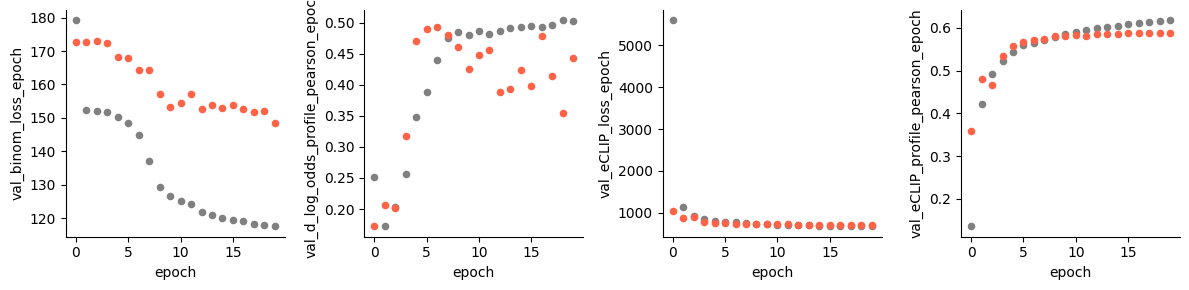

In [13]:
# plot training curve
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
f, axes = plt.subplots(1,4,figsize = (12,3))
metric_df = pd.read_csv(Path(log_dir) / 'metrics.csv')
metric_df.plot.scatter(x = 'epoch', y = 'train_binom_loss_epoch',
                    ax = axes[0], color = 'grey')
metric_df.plot.scatter(x = 'epoch', y = 'val_binom_loss_epoch',
                    ax = axes[0], color = 'tomato')

metric_df.plot.scatter(x = 'epoch',
                    y = 'train_d_log_odds_profile_pearson_epoch',
                    ax = axes[1], color = 'grey')
metric_df.plot.scatter(x = 'epoch',
                    y = 'val_d_log_odds_profile_pearson_epoch',
                    ax = axes[1], color = 'tomato')

metric_df.plot.scatter(x = 'epoch', y = 'train_eCLIP_loss_epoch',
                    ax = axes[2], color = 'grey')
metric_df.plot.scatter(x = 'epoch', y = 'val_eCLIP_loss_epoch',
                    ax = axes[2], color = 'tomato')

metric_df.plot.scatter(x = 'epoch', y = 'train_eCLIP_profile_pearson_epoch',
                    ax = axes[3], color = 'grey')
metric_df.plot.scatter(x = 'epoch', y = 'val_eCLIP_profile_pearson_epoch',
                    ax = axes[3], color = 'tomato')
plt.tight_layout()
plt.legend()
sns.despine()

In [26]:
best_path = trainer.checkpoint_callback.best_model_path

module = Module.load_from_checkpoint(
    best_path,
    arch=RBPNet(mask=100),
    input_variables=["seq"],
    output_variables=[
        "eCLIP_profile",
        "signal_profile",
        "control_profile",
        "mixing_coefficient",
        "d_log_odds"
    ],
    target_variables=[
        "signal",
        "control",
        "gc_fraction",
        "n_IN",
        "n_IP"
    ],
    loss_fxn=rbpnet_loss,
    metrics_fxn=rbpnet_metrics
)

In [28]:
module.eval()
device = next(module.parameters()).device

all_pred = []
all_pi = []
all_dlogodds = []
all_signal = []
all_gc = []
all_nIP = []
all_nIN = []
all_name = []
all_strand = []

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Predicting"):

        x = batch["seq"].to(device)

        # forward once
        outputs = module.arch(x)

        all_pred.append(outputs[0].cpu())
        all_pi.append(outputs[3].cpu())
        all_dlogodds.append(outputs[4].cpu())

        all_signal.append(batch["signal"].cpu())
        all_gc.append(batch["gc_fraction"].cpu())
        all_nIP.append(batch["n_IP"].cpu())
        all_nIN.append(batch["n_IN"].cpu())

        if "name" in batch:
            all_name.extend(batch["name"])

        if "strand" in batch:
            all_strand.extend(batch["strand"])


y_pred = torch.cat(all_pred)
pis = torch.cat(all_pi).squeeze()
dlogodds = torch.cat([
    x if x.dim() == 1 else x.unsqueeze(-1)
    for x in all_dlogodds
])

y_clip = torch.cat(all_signal)
gc_fraction = torch.cat(all_gc)
n_IP = torch.cat(all_nIP)
n_IN = torch.cat(all_nIN)

Predicting:   0%|          | 0/73 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Predicting: 100%|██████████| 73/73 [01:04<00:00,  1.14it/s]


In [29]:
# total counts
from metrics import pearson_corr
y_total = y_clip.sum(dim=1, keepdim=True)

# predicted profile
probs = torch.softmax(y_pred, dim=1)
expected_counts = probs * y_total

pearsons = pearson_corr(expected_counts, y_clip).cpu().numpy()

# compute d_log_odds from data
y_logodd, y_dlogodd = dlog_odds_from_data(
    {
        "n_IP": n_IP,
        "n_IN": n_IN,
        "gc_fraction": gc_fraction,
    }
)

# combine metrics for tests metrics
test_metrics = pd.DataFrame({
    'profile_pearsons': pearsons,
    'pi': pis.squeeze(),
    'dlogodds_pred': dlogodds,
    'dlogodds': y_dlogodd,
    'logodds': y_logodd,
    'n_IP': n_IP,
    'n_IN': n_IN,
    'gc_fraction': gc_fraction,
}
                        )
test_metrics['total'] = test_metrics['n_IP']+test_metrics['n_IN']



In [30]:
from scipy.stats import pearsonr
data_output = {}
for nread in [10,50,100,200]:
    # at low coverage region, the signal is noisy
    # the paper showed correlation > 50 reads
    pearson_means = test_metrics.loc[test_metrics['total']>nread, 'profile_pearsons'].mean()
    pearson_std = test_metrics.loc[test_metrics['total']>nread, 'profile_pearsons'].std()
    data_output[f'mean profile_pearson(total>{nread})']=pearson_means
    data_output[f'std profile_pearson(total>{nread})']=pearson_std

data_output['dlogodds pearson'], _=pearsonr(test_metrics['dlogodds'],test_metrics['dlogodds_pred'])

for nread in [10,50,100,200]:
    sub = test_metrics[test_metrics['total']>nread]
    r,p = pearsonr(sub['dlogodds'],sub['dlogodds_pred'])
    data_output[f'dlogodds pearson(total>{nread})']=r

    r,p = pearsonr(sub['pi'],sub['dlogodds_pred'])
    data_output[f'pi pearson(total>{nread})']=r

data_output

{'mean profile_pearson(total>10)': np.float32(0.6512904),
 'std profile_pearson(total>10)': 0.2738021910190582,
 'mean profile_pearson(total>50)': np.float32(0.7041746),
 'std profile_pearson(total>50)': 0.2792542576789856,
 'mean profile_pearson(total>100)': np.float32(0.6721861),
 'std profile_pearson(total>100)': 0.312958300113678,
 'mean profile_pearson(total>200)': np.float32(0.6210103),
 'std profile_pearson(total>200)': 0.3390648066997528,
 'dlogodds pearson': np.float32(0.44687474),
 'dlogodds pearson(total>10)': np.float32(0.4985944),
 'pi pearson(total>10)': np.float32(0.91740197),
 'dlogodds pearson(total>50)': np.float32(0.58875996),
 'pi pearson(total>50)': np.float32(0.94021666),
 'dlogodds pearson(total>100)': np.float32(0.68130916),
 'pi pearson(total>100)': np.float32(0.95582277),
 'dlogodds pearson(total>200)': np.float32(0.7434357),
 'pi pearson(total>200)': np.float32(0.966109)}

In [31]:
pd.Series(data_output).sort_index()

,0
dlogodds pearson,0.446875
dlogodds pearson(total>10),0.498594
dlogodds pearson(total>100),0.681309
dlogodds pearson(total>200),0.743436
dlogodds pearson(total>50),0.588760
mean profile_pearson(total>10),0.651290
mean profile_pearson(total>100),0.672186
mean profile_pearson(total>200),0.621010
mean profile_pearson(total>50),0.704175
pi pearson(total>10),0.917402


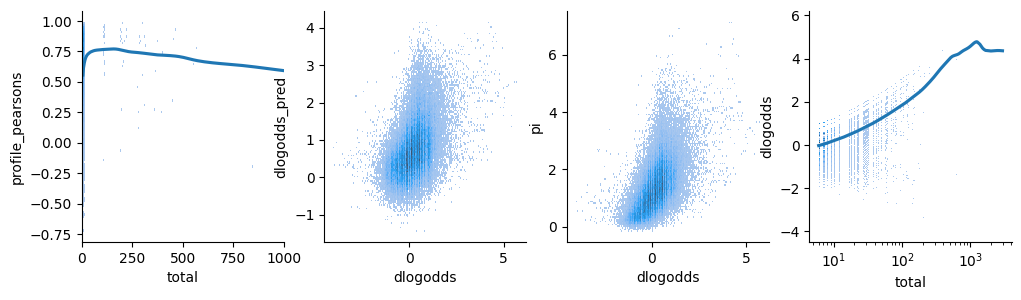

In [32]:
f, axes = plt.subplots(1,4, figsize = (12,3))
sns.histplot(data = test_metrics,x='total', y='profile_pearsons', ax = axes[0])
sns.regplot(data = test_metrics,x='total', y='profile_pearsons', scatter = False, ax = axes[0],lowess=True)
axes[0].set_xlim(0,1000)

sns.histplot(data = test_metrics, x='dlogodds', y='dlogodds_pred', ax = axes[1])

sns.histplot(data = test_metrics, x='dlogodds', y='pi', ax = axes[2])

sns.histplot(data =test_metrics, x='total', y='dlogodds', ax = axes[3])
sns.regplot(data =test_metrics, x='total', y='dlogodds', scatter = False, ax = axes[3],lowess=True)
axes[3].set_xscale('log')
sns.despine()

In [24]:
# download checkpoints
!zip -r log.zip log/
from google.colab import files
files.download("log.zip")

  adding: log/ (stored 0%)
  adding: log/metrics.csv (deflated 73%)
  adding: log/checkpoints/ (stored 0%)
  adding: log/checkpoints/epoch=2-step=4986.ckpt (deflated 16%)
  adding: log/checkpoints/epoch=4-step=8310.ckpt (deflated 16%)
  adding: log/checkpoints/epoch=15-step=26592.ckpt (deflated 15%)
  adding: log/checkpoints/epoch=3-step=6648.ckpt (deflated 16%)
  adding: log/checkpoints/epoch=5-step=9972.ckpt (deflated 16%)
  adding: log/checkpoints/epoch=18-step=31578.ckpt (deflated 16%)
  adding: log/checkpoints/epoch=13-step=23268.ckpt (deflated 15%)
  adding: log/checkpoints/epoch=12-step=21606.ckpt (deflated 15%)
  adding: log/checkpoints/epoch=19-step=33240.ckpt (deflated 16%)
  adding: log/checkpoints/epoch=1-step=3324.ckpt (deflated 17%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>